# 📊 Presentation Figures Generator

Generates all visualizations for the MathAI 2026 presentation:
- Slide 3: TPR gaps comparison (City vs Gender vs Age)
- Slide 4: Data distribution (cities, pie chart)
- Slide 5: Categories & Age groups distribution
- Slide 6: TPR gap visual explanation
- Slide 10/11: Debiasing results comparison

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Paths - adjust for your environment
# Colab: '/content/drive/MyDrive/resume-screening/'
# Local: Path(__file__).parent or './'
BASE_DIR = Path('.')  # Change if needed
DATA_DIR = Path('/Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository/data/processed')
FIG_DIR = BASE_DIR / 'figures'
FIG_DIR.mkdir(exist_ok=True)

# For high-quality figures
DPI = 150
FIGSIZE_WIDE = (12, 6)
FIGSIZE_SQUARE = (8, 8)
FIGSIZE_SMALL = (8, 5)

print(f"Saving figures to: {FIG_DIR.absolute()}")

Saving figures to: /Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository/experiments/figures


In [7]:
# Load data (file existence errors should not occur - files are present)

def safe_read_csv(path, name):
    df = pd.read_csv(path)
    print(f"✅ Loaded {name} ({len(df):,} rows): {path}")
    return df

df_train = safe_read_csv(DATA_DIR / 'train.csv', 'train.csv')
df_val   = safe_read_csv(DATA_DIR / 'val.csv', 'val.csv')
df_test  = safe_read_csv(DATA_DIR / 'test.csv', 'test.csv')

# Concatenate all splits (files are guaranteed to exist)
df_all = pd.concat([df_train, df_val, df_test], ignore_index=True)
# Load supercategory mapping (assume file exists)
mapping = pd.read_csv(DATA_DIR / 'label_to_supercategory_v1.csv')
label_to_supercat = dict(zip(mapping['label'], mapping['supercategory']))
df_all['supercategory'] = df_all['label'].map(label_to_supercat)

print(f"Total samples: {len(df_all):,}")
print(f"Train: {len(df_train):,}, "
      f"Val: {len(df_val):,}, "
      f"Test: {len(df_test):,}")
if 'city_group' in df_all.columns:
    print(f"Cities: {df_all['city_group'].nunique()}")
else:
    print("Column 'city_group' not found in data.")
if 'supercategory' in df_all.columns:
    print(f"Categories: {df_all['supercategory'].nunique()}")
else:
    print("Column 'supercategory' not found in data.")

✅ Loaded train.csv (16,530 rows): /Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository/data/processed/train.csv
✅ Loaded val.csv (5,510 rows): /Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository/data/processed/val.csv
✅ Loaded test.csv (5,510 rows): /Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository/data/processed/test.csv
Total samples: 27,550
Train: 16,530, Val: 5,510, Test: 5,510
Cities: 41
Categories: 9


## Slide 3: TPR Gaps by Attribute (Bar Chart)

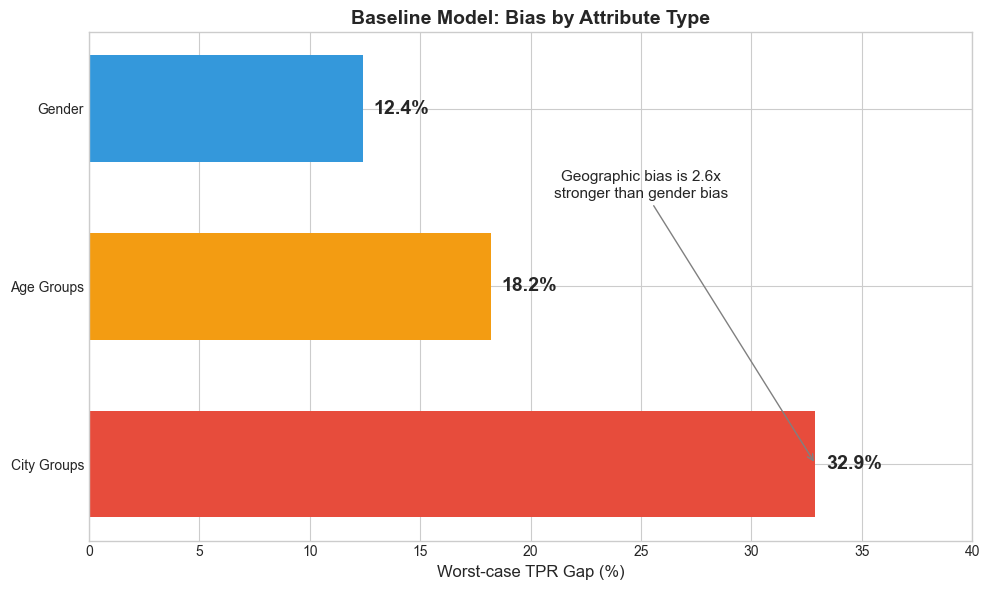

✅ Saved: slide3_tpr_gaps_by_attribute.png


In [8]:
# Data from paper
tpr_gaps = {
    'City Groups': 32.9,
    'Age Groups': 18.2,
    'Gender': 12.4
}

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#e74c3c', '#f39c12', '#3498db']  # Red, Orange, Blue
bars = ax.barh(list(tpr_gaps.keys()), list(tpr_gaps.values()), color=colors, height=0.6)

# Add value labels
for bar, val in zip(bars, tpr_gaps.values()):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val}%', 
            va='center', fontsize=14, fontweight='bold')

ax.set_xlabel('Worst-case TPR Gap (%)', fontsize=12)
ax.set_title('Baseline Model: Bias by Attribute Type', fontsize=14, fontweight='bold')
ax.set_xlim(0, 40)
ax.axvline(x=0, color='black', linewidth=0.5)

# Highlight the main finding
ax.annotate('Geographic bias is 2.6x\nstronger than gender bias', 
            xy=(32.9, 0), xytext=(25, 1.5),
            fontsize=11, ha='center',
            arrowprops=dict(arrowstyle='->', color='gray'))

plt.tight_layout()
plt.savefig(FIG_DIR / 'slide3_tpr_gaps_by_attribute.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("✅ Saved: slide3_tpr_gaps_by_attribute.png")

## Slide 4: Data Distribution - Cities

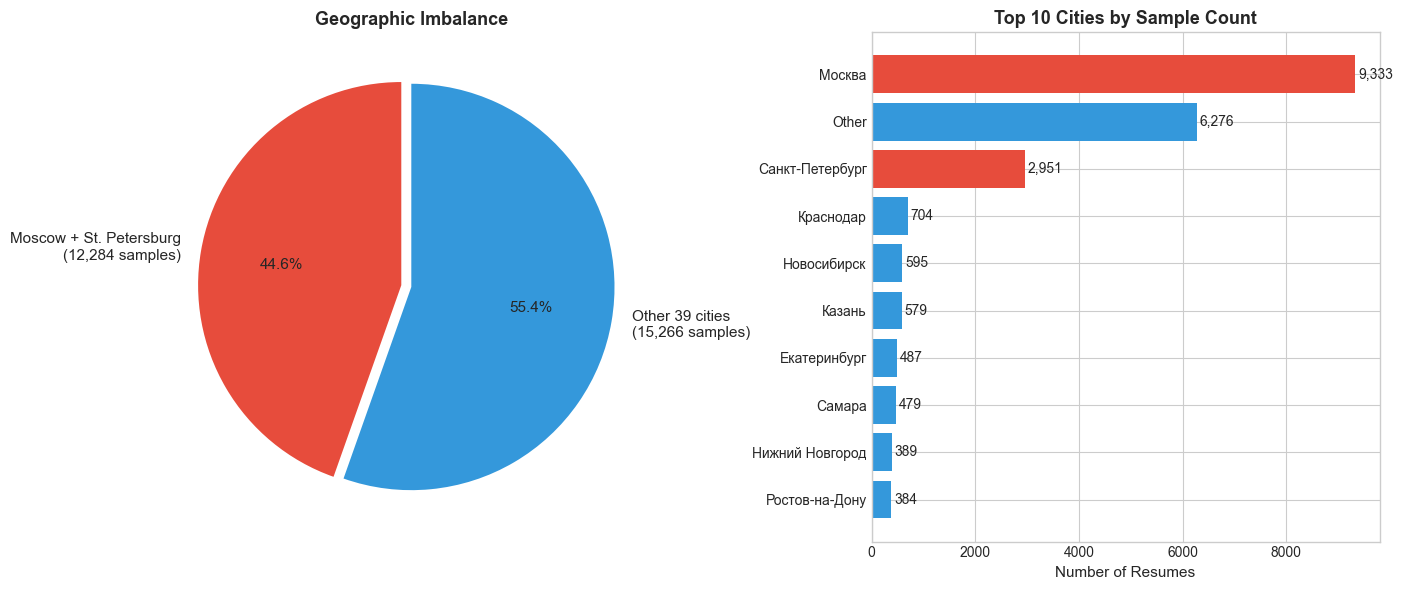

✅ Saved: slide4_city_distribution.png


In [9]:
# City distribution
city_counts = df_all['city_group'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Pie chart - Moscow + SPb vs Regions
moscow_spb = city_counts.get('Москва', 0) + city_counts.get('Санкт-Петербург', 0)
regions = city_counts.sum() - moscow_spb

sizes = [moscow_spb, regions]
labels = [f'Moscow + St. Petersburg\n({moscow_spb:,} samples)', 
          f'Other 39 cities\n({regions:,} samples)']
colors = ['#e74c3c', '#3498db']
explode = (0.05, 0)

axes[0].pie(sizes, labels=labels, colors=colors, explode=explode,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11})
axes[0].set_title('Geographic Imbalance', fontsize=13, fontweight='bold')

# Right: Top 10 cities bar chart
top10 = city_counts.head(10)
colors_bar = ['#e74c3c' if c in ['Москва', 'Санкт-Петербург'] else '#3498db' 
              for c in top10.index]

bars = axes[1].barh(range(len(top10)), top10.values, color=colors_bar)
axes[1].set_yticks(range(len(top10)))
axes[1].set_yticklabels(top10.index)
axes[1].invert_yaxis()
axes[1].set_xlabel('Number of Resumes', fontsize=11)
axes[1].set_title('Top 10 Cities by Sample Count', fontsize=13, fontweight='bold')

# Add count labels
for i, (bar, val) in enumerate(zip(bars, top10.values)):
    axes[1].text(val + 50, i, f'{val:,}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig(FIG_DIR / 'slide4_city_distribution.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("✅ Saved: slide4_city_distribution.png")

## Slide 5: Categories & Age Distribution

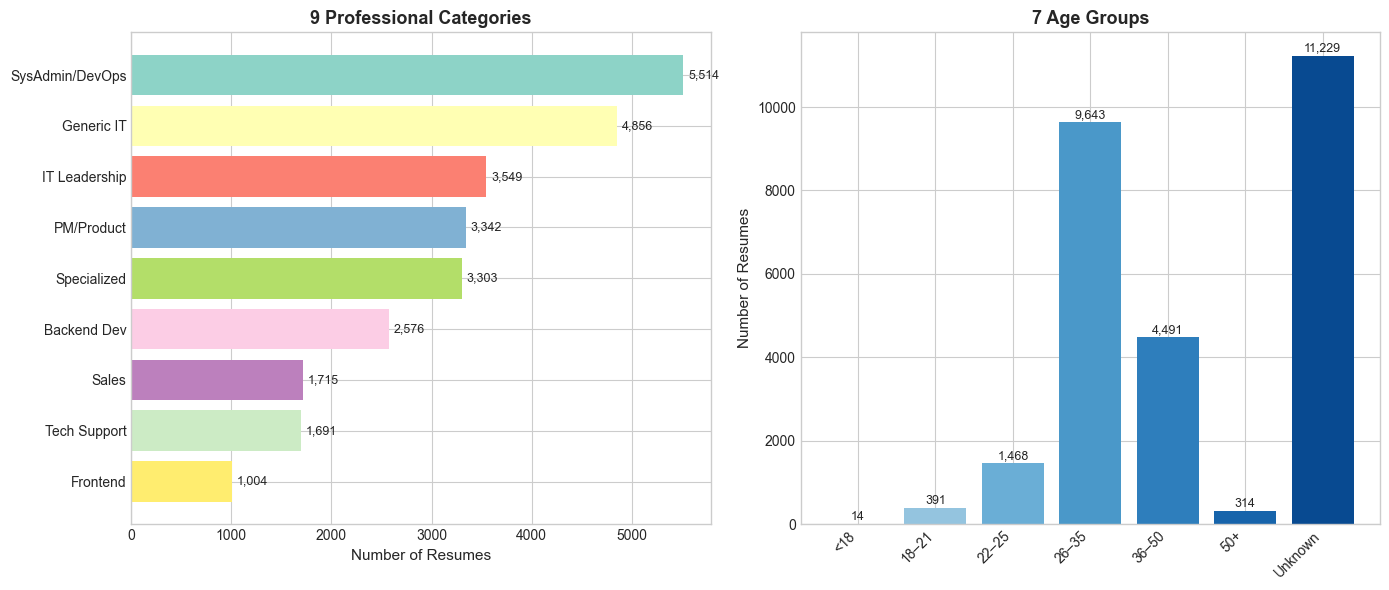

✅ Saved: slide5_categories_age.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: 9 Supercategories
cat_counts = df_all['supercategory'].value_counts()

# Shorter names for display
cat_short = {
    'backend_general_dev': 'Backend Dev',
    'web_frontend': 'Frontend',
    'sysadmin_devops_network': 'SysAdmin/DevOps',
    'project_product': 'PM/Product',
    'sales_account': 'Sales',
    'tech_support_helpdesk': 'Tech Support',
    'it_governance_leadership': 'IT Leadership',
    'technical_specialized': 'Specialized',
    'generic_it_ops': 'Generic IT'
}

cat_labels = [cat_short.get(c, c) for c in cat_counts.index]
colors_cat = plt.cm.Set3(np.linspace(0, 1, len(cat_counts)))

bars = axes[0].barh(range(len(cat_counts)), cat_counts.values, color=colors_cat)
axes[0].set_yticks(range(len(cat_counts)))
axes[0].set_yticklabels(cat_labels)
axes[0].invert_yaxis()
axes[0].set_xlabel('Number of Resumes', fontsize=11)
axes[0].set_title('9 Professional Categories', fontsize=13, fontweight='bold')

for i, val in enumerate(cat_counts.values):
    axes[0].text(val + 50, i, f'{val:,}', va='center', fontsize=9)

# Right: Age groups
if 'age_group' in df_all.columns:
    age_order = ['<18', '18–21', '22–25', '26–35', '36–50', '50+', 'Unknown']
    age_counts = df_all['age_group'].value_counts()
    # Reorder
    age_counts = age_counts.reindex([a for a in age_order if a in age_counts.index])
    
    colors_age = plt.cm.Blues(np.linspace(0.3, 0.9, len(age_counts)))
    bars = axes[1].bar(range(len(age_counts)), age_counts.values, color=colors_age)
    axes[1].set_xticks(range(len(age_counts)))
    axes[1].set_xticklabels(age_counts.index, rotation=45, ha='right')
    axes[1].set_ylabel('Number of Resumes', fontsize=11)
    axes[1].set_title('7 Age Groups', fontsize=13, fontweight='bold')
    
    for i, val in enumerate(age_counts.values):
        axes[1].text(i, val + 100, f'{val:,}', ha='center', fontsize=9)
else:
    axes[1].text(0.5, 0.5, 'Age group data\nnot available', 
                 ha='center', va='center', fontsize=14, transform=axes[1].transAxes)
    axes[1].set_title('7 Age Groups', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(FIG_DIR / 'slide5_categories_age.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("✅ Saved: slide5_categories_age.png")

## Slide 5b: Train/Val/Test Split

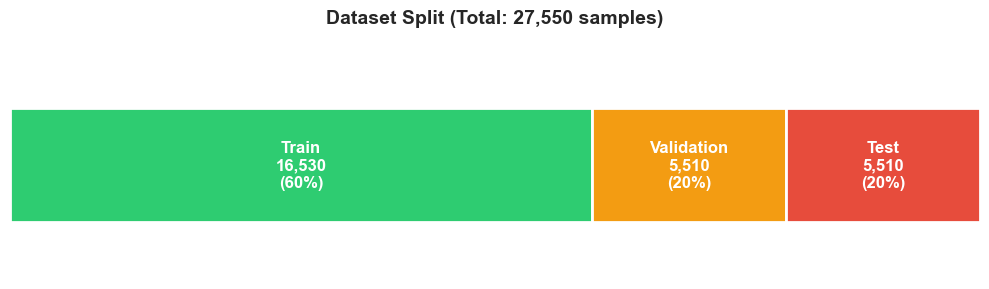

✅ Saved: slide5b_train_val_test_split.png


In [11]:
fig, ax = plt.subplots(figsize=(10, 3))

splits = {'Train': len(df_train), 'Validation': len(df_val), 'Test': len(df_test)}
total = sum(splits.values())

colors = ['#2ecc71', '#f39c12', '#e74c3c']
left = 0

for (name, count), color in zip(splits.items(), colors):
    width = count / total
    ax.barh(0, width, left=left, color=color, height=0.5, edgecolor='white', linewidth=2)
    ax.text(left + width/2, 0, f'{name}\n{count:,}\n({width*100:.0f}%)', 
            ha='center', va='center', fontsize=12, fontweight='bold', color='white')
    left += width

ax.set_xlim(0, 1)
ax.set_ylim(-0.5, 0.5)
ax.axis('off')
ax.set_title(f'Dataset Split (Total: {total:,} samples)', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(FIG_DIR / 'slide5b_train_val_test_split.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("✅ Saved: slide5b_train_val_test_split.png")

## Slide 6: TPR Gap Visual Explanation

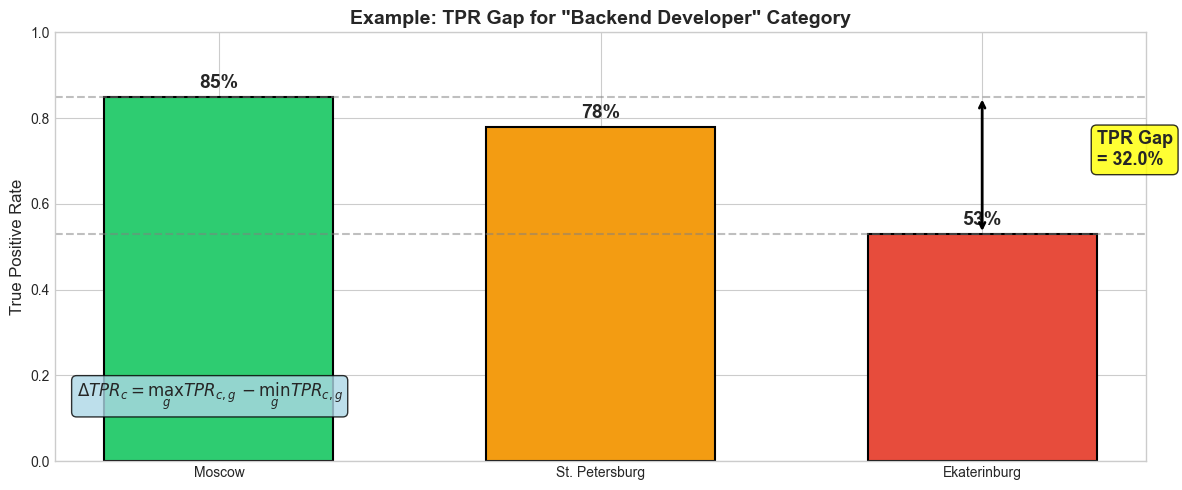

✅ Saved: slide6_tpr_gap_explanation.png


In [12]:
fig, ax = plt.subplots(figsize=(12, 5))

# Example: TPR for Backend Dev across 3 groups
groups = ['Moscow', 'St. Petersburg', 'Ekaterinburg']
tprs = [0.85, 0.78, 0.53]  # Example values
colors = ['#2ecc71', '#f39c12', '#e74c3c']

bars = ax.bar(groups, tprs, color=colors, width=0.6, edgecolor='black', linewidth=1.5)

# Add TPR values on bars
for bar, tpr in zip(bars, tprs):
    ax.text(bar.get_x() + bar.get_width()/2, tpr + 0.02, f'{tpr:.0%}', 
            ha='center', fontsize=14, fontweight='bold')

# Draw gap annotation
ax.annotate('', xy=(2, 0.85), xytext=(2, 0.53),
            arrowprops=dict(arrowstyle='<->', color='black', lw=2))
ax.text(2.3, 0.69, f'TPR Gap\n= {(0.85-0.53)*100:.1f}%', fontsize=13, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8))

ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_ylim(0, 1.0)
ax.set_title('Example: TPR Gap for "Backend Developer" Category', fontsize=14, fontweight='bold')
ax.axhline(y=0.85, color='gray', linestyle='--', alpha=0.5, label='Best group')
ax.axhline(y=0.53, color='gray', linestyle='--', alpha=0.5, label='Worst group')

# Formula
ax.text(0.02, 0.15, r'$\Delta TPR_c = \max_g TPR_{c,g} - \min_g TPR_{c,g}$', 
        transform=ax.transAxes, fontsize=12, 
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.tight_layout()
plt.savefig(FIG_DIR / 'slide6_tpr_gap_explanation.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("✅ Saved: slide6_tpr_gap_explanation.png")

## Slide 10/11: Debiasing Results Comparison

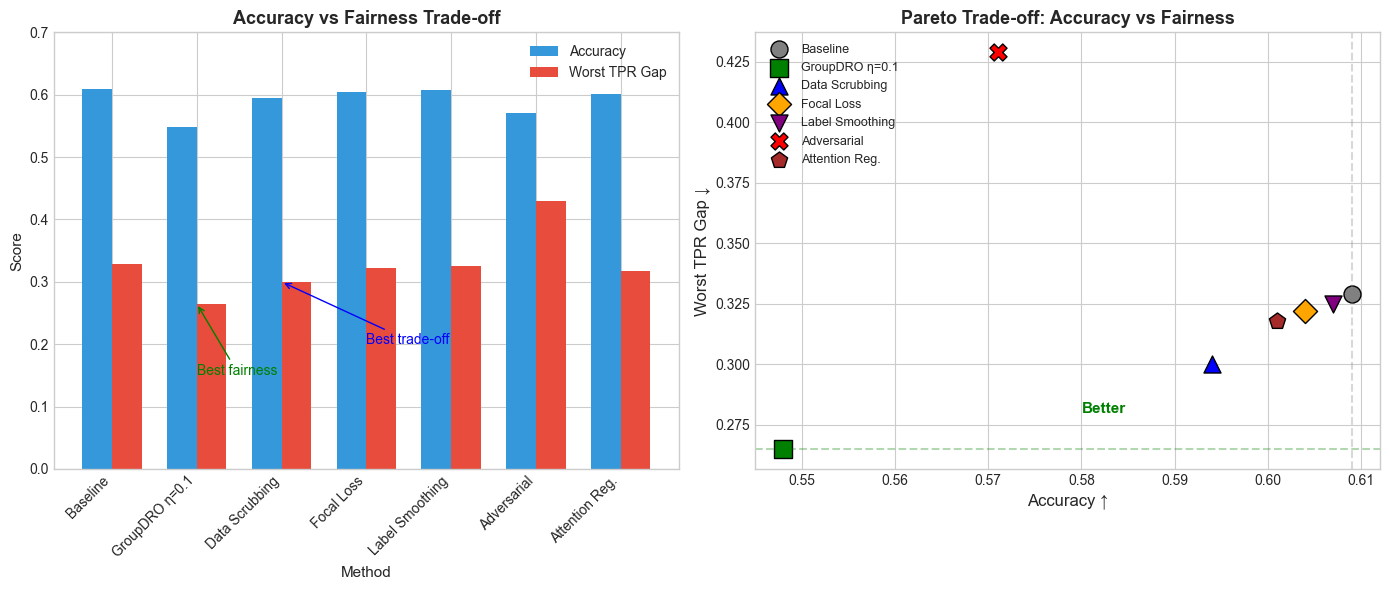

✅ Saved: slide11_debiasing_results.png


In [13]:
# Results from paper Table 1 & 2
results = pd.DataFrame({
    'Method': ['Baseline', 'GroupDRO η=0.1', 'Data Scrubbing', 'Focal Loss', 
               'Label Smoothing', 'Adversarial', 'Attention Reg.'],
    'Accuracy': [0.609, 0.548, 0.594, 0.604, 0.607, 0.571, 0.601],
    'Macro F1': [0.621, 0.553, 0.611, 0.616, 0.619, 0.582, 0.612],
    'Worst Gap': [0.329, 0.265, 0.300, 0.322, 0.325, 0.429, 0.318],
    'Macro Gap': [0.116, 0.113, 0.112, 0.115, 0.116, 0.142, 0.114]
})

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Grouped bar chart
x = np.arange(len(results))
width = 0.35

bars1 = axes[0].bar(x - width/2, results['Accuracy'], width, label='Accuracy', color='#3498db')
bars2 = axes[0].bar(x + width/2, results['Worst Gap'], width, label='Worst TPR Gap', color='#e74c3c')

axes[0].set_xlabel('Method', fontsize=11)
axes[0].set_ylabel('Score', fontsize=11)
axes[0].set_title('Accuracy vs Fairness Trade-off', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(results['Method'], rotation=45, ha='right')
axes[0].legend()
axes[0].set_ylim(0, 0.7)

# Highlight best
axes[0].annotate('Best fairness', xy=(1, 0.265), xytext=(1, 0.15),
                arrowprops=dict(arrowstyle='->', color='green'), fontsize=10, color='green')
axes[0].annotate('Best trade-off', xy=(2, 0.30), xytext=(3, 0.20),
                arrowprops=dict(arrowstyle='->', color='blue'), fontsize=10, color='blue')

# Right: Scatter plot (Pareto frontier)
colors_scatter = ['gray', 'green', 'blue', 'orange', 'purple', 'red', 'brown']
markers = ['o', 's', '^', 'D', 'v', 'X', 'p']

for i, row in results.iterrows():
    axes[1].scatter(row['Accuracy'], row['Worst Gap'], 
                   c=colors_scatter[i], marker=markers[i], s=150, 
                   label=row['Method'], edgecolors='black', linewidth=1)

axes[1].set_xlabel('Accuracy ↑', fontsize=12)
axes[1].set_ylabel('Worst TPR Gap ↓', fontsize=12)
axes[1].set_title('Pareto Trade-off: Accuracy vs Fairness', fontsize=13, fontweight='bold')
axes[1].legend(loc='upper left', fontsize=9)

# Add ideal direction arrow
axes[1].annotate('', xy=(0.62, 0.25), xytext=(0.55, 0.35),
                arrowprops=dict(arrowstyle='->', color='green', lw=2))
axes[1].text(0.58, 0.28, 'Better', fontsize=11, color='green', fontweight='bold')

# Highlight Pareto optimal
axes[1].axhline(y=0.265, color='green', linestyle='--', alpha=0.3)
axes[1].axvline(x=0.609, color='gray', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'slide11_debiasing_results.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("✅ Saved: slide11_debiasing_results.png")

## Slide 10: Debiasing Methods Overview (Table/Diagram)

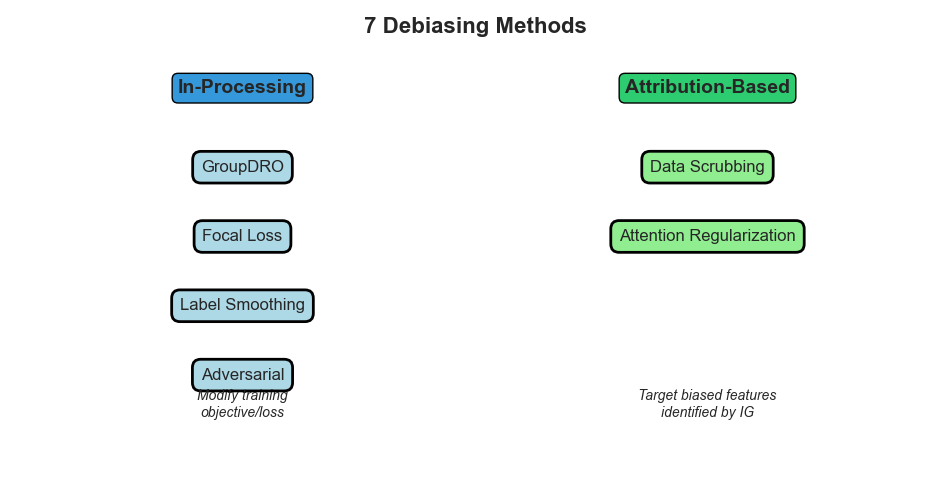

✅ Saved: slide10_methods_overview.png


In [14]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('off')

# Two columns: In-processing vs Attribution-based
inproc = ['GroupDRO', 'Focal Loss', 'Label Smoothing', 'Adversarial']
attrib = ['Data Scrubbing', 'Attention Regularization']

# Draw boxes
box_style = dict(boxstyle='round,pad=0.5', facecolor='lightblue', edgecolor='black', linewidth=2)
box_style2 = dict(boxstyle='round,pad=0.5', facecolor='lightgreen', edgecolor='black', linewidth=2)

# Title
ax.text(0.5, 0.95, '7 Debiasing Methods', fontsize=16, fontweight='bold', 
        ha='center', transform=ax.transAxes)

# In-processing column
ax.text(0.25, 0.82, 'In-Processing', fontsize=14, fontweight='bold', 
        ha='center', transform=ax.transAxes, 
        bbox=dict(boxstyle='round', facecolor='#3498db', edgecolor='black'))

for i, method in enumerate(inproc):
    y = 0.65 - i * 0.15
    ax.text(0.25, y, method, fontsize=12, ha='center', transform=ax.transAxes, bbox=box_style)

# Attribution-based column
ax.text(0.75, 0.82, 'Attribution-Based', fontsize=14, fontweight='bold', 
        ha='center', transform=ax.transAxes,
        bbox=dict(boxstyle='round', facecolor='#2ecc71', edgecolor='black'))

for i, method in enumerate(attrib):
    y = 0.65 - i * 0.15
    ax.text(0.75, y, method, fontsize=12, ha='center', transform=ax.transAxes, bbox=box_style2)

# Add descriptions
ax.text(0.25, 0.12, 'Modify training\nobjective/loss', fontsize=10, ha='center', 
        transform=ax.transAxes, style='italic')
ax.text(0.75, 0.12, 'Target biased features\nidentified by IG', fontsize=10, ha='center', 
        transform=ax.transAxes, style='italic')

plt.savefig(FIG_DIR / 'slide10_methods_overview.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("✅ Saved: slide10_methods_overview.png")

## Slide 7: Integrated Gradients Process Diagram

/var/folders/hh/cj64t6m14sd46vthykgl9lwc0000gn/T/ipykernel_88028/837373322.py:49: UserWarning: Glyph 8712 (\N{ELEMENT OF}) missing from font(s) Arial.
  plt.savefig(FIG_DIR / 'slide7_ig_process.png', dpi=DPI, bbox_inches='tight')
/var/folders/hh/cj64t6m14sd46vthykgl9lwc0000gn/T/ipykernel_88028/837373322.py:49: UserWarning: Glyph 8711 (\N{NABLA}) missing from font(s) Arial.
  plt.savefig(FIG_DIR / 'slide7_ig_process.png', dpi=DPI, bbox_inches='tight')
/Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8712 (\N{ELEMENT OF}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8711 (\N{NABLA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


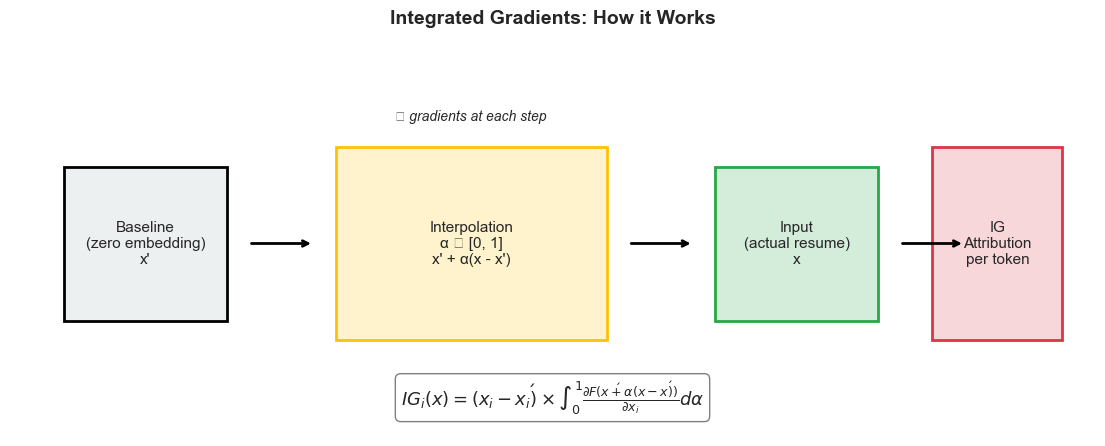

✅ Saved: slide7_ig_process.png


In [15]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.axis('off')

# Draw the IG process: Baseline -> Interpolation -> Input
# Baseline box
ax.add_patch(plt.Rectangle((0.05, 0.3), 0.15, 0.4, fill=True, 
                            facecolor='#ecf0f1', edgecolor='black', linewidth=2))
ax.text(0.125, 0.5, 'Baseline\n(zero embedding)\nx\'', fontsize=11, ha='center', va='center')

# Arrow 1
ax.annotate('', xy=(0.28, 0.5), xytext=(0.22, 0.5),
            arrowprops=dict(arrowstyle='->', color='black', lw=2))

# Interpolation
ax.add_patch(plt.Rectangle((0.30, 0.25), 0.25, 0.5, fill=True, 
                            facecolor='#fff3cd', edgecolor='#ffc107', linewidth=2))
ax.text(0.425, 0.5, 'Interpolation\nα ∈ [0, 1]\nx\' + α(x - x\')', fontsize=11, ha='center', va='center')

# Gradient symbols
ax.text(0.425, 0.82, '∇ gradients at each step', fontsize=10, ha='center', style='italic')

# Arrow 2
ax.annotate('', xy=(0.63, 0.5), xytext=(0.57, 0.5),
            arrowprops=dict(arrowstyle='->', color='black', lw=2))

# Input box
ax.add_patch(plt.Rectangle((0.65, 0.3), 0.15, 0.4, fill=True, 
                            facecolor='#d4edda', edgecolor='#28a745', linewidth=2))
ax.text(0.725, 0.5, 'Input\n(actual resume)\nx', fontsize=11, ha='center', va='center')

# Arrow 3
ax.annotate('', xy=(0.88, 0.5), xytext=(0.82, 0.5),
            arrowprops=dict(arrowstyle='->', color='black', lw=2))

# Attribution output
ax.add_patch(plt.Rectangle((0.85, 0.25), 0.12, 0.5, fill=True, 
                            facecolor='#f8d7da', edgecolor='#dc3545', linewidth=2))
ax.text(0.91, 0.5, 'IG\nAttribution\nper token', fontsize=11, ha='center', va='center')

# Formula at bottom
ax.text(0.5, 0.08, r'$IG_i(x) = (x_i - x_i\') \times \int_0^1 \frac{\partial F(x\' + \alpha(x-x\'))}{\partial x_i} d\alpha$', 
        fontsize=13, ha='center', transform=ax.transAxes,
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray'))

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title('Integrated Gradients: How it Works', fontsize=14, fontweight='bold', pad=20)

plt.savefig(FIG_DIR / 'slide7_ig_process.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("✅ Saved: slide7_ig_process.png")

## Summary: All Generated Figures

In [16]:
print("\n" + "="*50)
print("📁 Generated Figures:")
print("="*50)

for f in sorted(FIG_DIR.glob('slide*.png')):
    size_kb = f.stat().st_size / 1024
    print(f"  ✅ {f.name} ({size_kb:.1f} KB)")

print("\n" + "="*50)
print(f"Total: {len(list(FIG_DIR.glob('slide*.png')))} figures")
print(f"Location: {FIG_DIR.absolute()}")
print("="*50)


📁 Generated Figures:
  ✅ slide10_methods_overview.png (61.7 KB)
  ✅ slide11_debiasing_results.png (122.7 KB)
  ✅ slide3_tpr_gaps_by_attribute.png (53.6 KB)
  ✅ slide4_city_distribution.png (97.0 KB)
  ✅ slide5_categories_age.png (75.7 KB)
  ✅ slide5b_train_val_test_split.png (29.3 KB)
  ✅ slide6_tpr_gap_explanation.png (55.7 KB)
  ✅ slide7_ig_process.png (50.2 KB)

Total: 8 figures
Location: /Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository/experiments/figures
